# Application Anchor — 24 short legal / news / regulatory docs (triple gold + provenance)

This notebook is a **runnable demo of the `Application Anchor` dataset**: a merged,
schema-validated corpus of short, professionally-written documents standardized to a
shared **`(head, relation, tail)`** triple space with **character-span provenance** and
coarse **`{PER, LOC, ORG, TIME, NUM, MISC}`** entity typing.

Each document is **one example**. The dataset is grouped by source corpus:

| Genre | Source corpus | Gold quality | License |
|-------|---------------|--------------|---------|
| legal | CUAD v1 (human-annotated clause spans) | **crisp** | CC BY 4.0 |
| news | Wikinews (deterministic spaCy SVO+5W) | silver | CC BY 2.5 |
| regulatory (EU) | GDPR / Reg (EU) 2016/679 | silver | EUR-Lex free reuse |
| regulatory (US) | eCFR | silver | US public domain |

It is the genre-faithful real-document slice that a downstream
**text → FOL → Prolog neuro-symbolic atomic-fact-extraction & hallucination-control**
experiment depends on. **No LLM is used anywhere in gold construction** (this preserves
non-circularity for the next-iteration hallucination experiment).

**What this demo does** — it loads a 12-document subset (3 per source corpus, all 3
genres) and runs the dataset's *own* tooling on it:

1. Inspect the per-example schema (the JSON-string `input` / `output` payloads).
2. **`verify_dataset.py`** — independently re-check every entity char-span, every fact
   provenance span, entity/type validity, and head/tail entity-linking coverage.
3. **`data.py : build_meta()`** — recompute the dataset composition summary.
4. Visualize the composition (genre / entity-type / relation / facts distributions).


## Setup

Install dependencies. On Colab the core scientific packages are pre-installed, so they are only installed locally (at Colab's exact versions) to mirror the Colab environment. The dataset's analysis code itself is pure Python standard library.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# matplotlib + pandas are pre-installed on Colab -> only install locally (Colab's versions).
# (The verification / build_meta code uses only the Python standard library.)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


Imports. The first block is copied verbatim from the artifact's `data.py` / `verify_dataset.py` (the `loguru` logger is dropped — it was only used by `data.py:main()`, which rebuilds the corpus from a raw snapshot and is not part of this demo). The second block adds plotting / table helpers for the notebook.

In [2]:
# --- original imports from data.py / verify_dataset.py ---
from __future__ import annotations
import os, sys, json, glob, statistics, hashlib
from pathlib import Path
from collections import Counter, defaultdict

# --- added for the notebook demo (tables + plots) ---
import pandas as pd
import matplotlib.pyplot as plt


### Load the dataset

Loads the curated demo subset from GitHub, with a local fallback to `mini_demo_data.json` so the notebook works both in Colab (after deployment) and locally (now).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-2/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
print("top-level keys :", list(data.keys()))
print("source corpora :", [(g["dataset"], len(g["examples"])) for g in data["datasets"]])
print("dataset name   :", data["metadata"]["name"])


top-level keys : ['metadata', 'datasets']
source corpora : [('CUAD', 3), ('Wikinews', 3), ('GDPR', 3), ('eCFR', 3)]
dataset name   : application_anchor


## Config

All tunable demo parameters live here. `N_PER_GROUP` controls how many documents are taken from **each** source corpus (the curated demo file holds 3 per corpus = 12 docs across all 3 genres; the full dataset has 8 per genre = 24). Start at the minimum and scale up — the whole demo runs in well under a second at any setting.

In [5]:
# --- tunable demo parameters (start minimal, scale up freely) ---
N_PER_GROUP = 3          # docs to take from EACH source corpus. mini file has 3/group (max).
N_PREVIEW   = 1          # how many full example payloads to print in detail

# --- constants copied from the artifact's verify_dataset.py / data.py ---
COARSE       = {"PER", "LOC", "ORG", "TIME", "NUM", "MISC"}   # coarse entity-type set
SEED         = 42                                             # data.py determinism seed
CORPUS_ORDER = ["CUAD", "Wikinews", "GDPR", "eCFR"]           # stable source-group order
TOOL_VERSIONS = {
    "python": "3.12", "spacy": "3.7.5", "spacy_model": "en_core_web_sm==3.7.1",
    "nltk": "3.9.1 (wordnet, omw-1.4)", "numpy": "1.26.4",
    "beautifulsoup4": "4.12.3 (lxml 5.3.0 parser)",
    "reserved_next_iteration": "sentence-transformers all-MiniLM-L6-v2, rank_bm25 "
                               "(NOT used for gold here; reserved for next-iteration "
                               "relation-alignment / retrieval)",
}


## Build the document row-set

The published file groups examples by source corpus (`datasets[]`). Flatten it back into a flat list of document *rows*, taking the first `N_PER_GROUP` documents from each corpus. Each row is **one document = one example**.

In [6]:
rows = []
for group in data["datasets"]:
    rows.extend(group["examples"][:N_PER_GROUP])

print(f"using {len(rows)} document rows from {len(data['datasets'])} source corpora")
print("per-corpus counts:",
      [(g["dataset"], min(N_PER_GROUP, len(g["examples"]))) for g in data["datasets"]])


using 12 document rows from 4 source corpora
per-corpus counts: [('CUAD', 3), ('Wikinews', 3), ('GDPR', 3), ('eCFR', 3)]


## Inspect the per-example schema

Each example's `input` and `output` are **JSON strings**. After `json.loads`:

* **input**  → `{doc_id, document_text, genre, source, char_length, entities:[{name, type, char_span}]}`
* **output** → `{gold_atomic_facts:[{head, relation, tail, provenance_char_span}]}`

The `corpus_of` helper below is copied verbatim from `data.py`.

In [7]:
def corpus_of(source: str) -> str:        # copied verbatim from data.py
    return source.split(":")[0]

for ex in rows[:N_PREVIEW]:
    inp = json.loads(ex["input"])         # input is a JSON STRING
    out = json.loads(ex["output"])        # output is a JSON STRING
    print("=" * 78)
    print("doc_id      :", inp["doc_id"], "| genre:", inp["genre"], "| corpus:", corpus_of(ex["metadata_source"]))
    print("gold_quality:", ex["metadata_gold_quality"], "| license:", ex["metadata_license"][:48], "...")
    print("char_length :", inp["char_length"],
          "| #entities:", len(inp["entities"]), "| #facts:", len(out["gold_atomic_facts"]))
    print("-- document_text (first 280 chars) --")
    print("  ", inp["document_text"][:280].replace("\n", " "))
    print("-- first 5 typed entities (name | coarse type | char_span -> verbatim slice) --")
    for e in inp["entities"][:5]:
        s, end = e["char_span"]
        print(f"   {e['name']!r:>42}  {e['type']:5} {e['char_span']}  ->  {inp['document_text'][s:end]!r}")
    print("-- gold_atomic_facts: head -[relation]-> tail (with provenance span) --")
    for f in out["gold_atomic_facts"]:
        print(f"   {f['head']!r} -[{f['relation']}]-> {f['tail']!r}   prov={f['provenance_char_span']}")


doc_id      : legal_cuad_00 | genre: legal | corpus: CUAD
gold_quality: crisp | license: CC BY 4.0 (Atticus Project / CUAD v1; Zenodo 459 ...
char_length : 2010 | #entities: 34 | #facts: 6
-- document_text (first 280 chars) --
   03/01/05  607-1295 Richards Street   604.684.2255  Vancouver, BC V6B1B7   deep@rrt.ca   deep systems      Premium Managed Hosting Agreement  This is a managed hosting agreement between AstroNutrition.com and deep systems.  The effective term is 12 months beginning March 1, 2005 a
-- first 5 typed entities (name | coarse type | char_span -> verbatim slice) --
          'Premium Managed Hosting Agreement'  MISC  [106, 139]  ->  'Premium Managed Hosting Agreement'
                                  'Vancouver'  LOC   [51, 60]  ->  'Vancouver'
                                  'BC V6B1B7'  LOC   [62, 71]  ->  'BC V6B1B7'
                         'AstroNutrition.com'  ORG   [185, 203]  ->  'AstroNutrition.com'
          '12 months beginning March 1, 2005'  TIME  [24

## Verify every invariant (`verify_dataset.py`)

This cell is the core of the artifact's **independent** verifier (`build/verify_dataset.py`), adapted only to iterate over the loaded `rows` instead of reading `data_out.json` from disk. It re-checks, from scratch, every claim the dataset makes:

1. JSON-parse every `input` / `output` string.
2. `char_length == len(document_text)` and length-band sanity.
3. Every entity `char_span` satisfies `document_text[s:e] == name`.
4. Every entity type is in the coarse set.
5. Every fact provenance span is valid & non-empty; value-tail facts have `tail` inside the span.
6. Head/tail entity-linking coverage (how many fact endpoints appear in the document text).

In [8]:
# --- verify_dataset.py main(), adapted to run over the loaded `rows` ---
exs = rows
group_sizes = {g["dataset"]: min(N_PER_GROUP, len(g["examples"])) for g in data["datasets"]}
errors, warns = [], []
n_ent = n_ent_ok = 0
n_fact = n_fact_tail_in_span = 0
head_linked = tail_linked = 0
genres, quality, lic = Counter(), Counter(), Counter()
rels = Counter()
type_counts = Counter()
lens = []

for ex in exs:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    did = inp["doc_id"]
    dt = inp["document_text"]
    genres[inp["genre"]] += 1
    quality[ex["metadata_gold_quality"]] += 1
    lic[ex["metadata_license"]] += 1
    lens.append(len(dt))

    # length consistency
    if inp["char_length"] != len(dt):
        errors.append(f"{did}: char_length {inp['char_length']} != len {len(dt)}")
    if ex["metadata_char_length"] != len(dt):
        errors.append(f"{did}: metadata_char_length mismatch")
    if not (1100 <= len(dt) <= 3600):
        warns.append(f"{did}: length {len(dt)} outside ~1150-3550 band")

    ent_surfaces = set()
    for e in inp["entities"]:
        n_ent += 1
        s, ee = e["char_span"]
        type_counts[e["type"]] += 1
        if e["type"] not in COARSE:
            errors.append(f"{did}: bad entity type {e['type']}")
        if 0 <= s <= ee <= len(dt) and dt[s:ee] == e["name"]:
            n_ent_ok += 1
            ent_surfaces.add(e["name"])
        else:
            errors.append(f"{did}: entity span FAIL {e['name']!r} {e['char_span']}")

    facts = out["gold_atomic_facts"]
    if len(facts) < 3:
        warns.append(f"{did}: only {len(facts)} facts")
    for f in facts:
        n_fact += 1
        rels[f["relation"]] += 1
        s, ee = f["provenance_char_span"]
        if not (0 <= s < ee <= len(dt)):
            errors.append(f"{did}: bad provenance span {f['provenance_char_span']}")
            continue
        prov = dt[s:ee]
        if not prov.strip():
            errors.append(f"{did}: empty provenance for {f}")
        if f["tail"] in prov:
            n_fact_tail_in_span += 1
        # entity-linking coverage: do head/tail appear in the document?
        if f["head"] in dt:
            head_linked += 1
        if f["tail"] in dt:
            tail_linked += 1

print("=" * 64)
print(f"documents: {len(exs)}  | source-dataset groups: {group_sizes}")
print(f"genres={dict(genres)}")
print(f"gold_quality={dict(quality)}")
print("licenses:")
for k, v in lic.items():
    print(f"   {v:2d}  {k[:70]}")
print(f"char_length: min={min(lens)} max={max(lens)} mean={sum(lens)//len(lens)}")
print("-" * 64)
print(f"entities: {n_ent} | spans verified: {n_ent_ok}/{n_ent} ({100*n_ent_ok/n_ent:.1f}%)")
print(f"entity type dist: {dict(type_counts)}")
print(f"facts: {n_fact} | tail-in-provenance: {n_fact_tail_in_span}/{n_fact} "
      f"({100*n_fact_tail_in_span/n_fact:.1f}%) [rest are clause/label facts]")
print(f"fact head appears in doc: {head_linked}/{n_fact} ({100*head_linked/n_fact:.1f}%)")
print(f"fact tail appears in doc: {tail_linked}/{n_fact} ({100*tail_linked/n_fact:.1f}%)")
print(f"distinct relations: {len(rels)}")
print(f"top relations: {rels.most_common(12)}")
print("-" * 64)
print(f"ERRORS: {len(errors)}")
for e in errors[:30]:
    print("   ERR", e)
print(f"WARNINGS: {len(warns)}")
for w in warns[:20]:
    print("   warn", w)
print("=" * 64)
print("RESULT:", "PASS - all spans/types/lengths verified" if not errors
      else f"FAIL - {len(errors)} errors")


documents: 12  | source-dataset groups: {'CUAD': 3, 'Wikinews': 3, 'GDPR': 3, 'eCFR': 3}
genres={'legal': 3, 'news': 3, 'regulatory': 6}
gold_quality={'crisp': 3, 'silver': 9}
licenses:
    3  CC BY 4.0 (Atticus Project / CUAD v1; Zenodo 4595826)
    3  CC BY 2.5 (Wikinews / Wikimedia Foundation)
    3  EUR-Lex reuse (© European Union; Regulation (EU) 2016/679, CELEX:32016
    3  Public domain (US Government work; eCFR / GPO, ecfr.gov)
char_length: min=1239 max=3422 mean=2322
----------------------------------------------------------------
entities: 374 | spans verified: 374/374 (100.0%)
entity type dist: {'MISC': 66, 'LOC': 46, 'ORG': 74, 'TIME': 59, 'NUM': 69, 'PER': 60}
facts: 62 | tail-in-provenance: 61/62 (98.4%) [rest are clause/label facts]
fact head appears in doc: 62/62 (100.0%)
fact tail appears in doc: 61/62 (98.4%)
distinct relations: 19
top relations: [('cross_references', 16), ('has_party', 10), ('has_title', 9), ('occurred_on', 5), ('agreement_date', 3), ('obligates', 3)

## Recompute the composition summary (`data.py : build_meta`)

This cell is the artifact's own `build_meta()` from `data.py`, copied with one minimal change: `ROOT` points at the current working directory (the original used the script's own folder to fingerprint the raw snapshot). The `raw/` snapshot is not shipped with the demo, so the determinism manifest simply reports an empty cache — every *statistical* field is still computed live from the loaded rows.

In [9]:
ROOT = Path.cwd()        # minimal path fix: original used the script's own directory


def raw_manifest():      # copied from data.py (reports the cached raw/ snapshot, if present)
    man = {}
    cu = ROOT / "raw" / "cuad_data" / "CUADv1.json"
    if cu.exists():
        man["CUADv1.json"] = {"bytes": cu.stat().st_size,
                              "sha256_16": hashlib.sha256(cu.read_bytes()).hexdigest()[:16]}
    man["gdpr_html_files"] = len(glob.glob(str(ROOT / "raw" / "gdpr" / "art-*.html")))
    man["wikinews_article_files"] = len(glob.glob(str(ROOT / "raw" / "wikinews" / "article_*.json")))
    man["ecfr_xml_files"] = len(glob.glob(str(ROOT / "raw" / "ecfr" / "*.xml")))
    return man


def build_meta(rows):    # copied verbatim from data.py
    genres = Counter(r["metadata_genre"] for r in rows)
    quality = Counter(r["metadata_gold_quality"] for r in rows)
    qbyg = defaultdict(Counter); cbyg = Counter(); lic = Counter()
    relvocab = defaultdict(set); lens = []; nfacts = []; nents = []
    for r in rows:
        gg = r["metadata_genre"]
        qbyg[gg][r["metadata_gold_quality"]] += 1
        cbyg[corpus_of(r["metadata_source"])] += 1
        lic[r["metadata_license"]] += 1
        for rel in r["metadata_relation_vocab"]:
            relvocab[gg].add(rel)
        lens.append(r["metadata_char_length"]); nfacts.append(r["metadata_num_facts"])
        nents.append(r["metadata_num_entities"])
    return {
        "name": "application_anchor",
        "n_documents": len(rows),
        "n_source_datasets": len(set(corpus_of(r["metadata_source"]) for r in rows)),
        "genre_counts": dict(genres),
        "source_dataset_counts": dict(cbyg),
        "gold_quality_counts": dict(quality),
        "gold_quality_by_genre": {k: dict(v) for k, v in qbyg.items()},
        "license_counts": dict(lic),
        "relation_vocab_by_genre": {k: sorted(v) for k, v in relvocab.items()},
        "total_facts": sum(nfacts), "total_entities": sum(nents),
        "facts_per_doc": {"min": min(nfacts), "max": max(nfacts),
                          "mean": round(statistics.mean(nfacts), 2)},
        "char_length": {"min": min(lens), "max": max(lens),
                        "mean": round(statistics.mean(lens), 1),
                        "median": int(statistics.median(lens))},
        "determinism": {"seed": SEED, "tool_versions": TOOL_VERSIONS,
                        "raw_cache_manifest": raw_manifest()},
    }


meta = build_meta(rows)
for k in ["n_documents", "n_source_datasets", "genre_counts", "source_dataset_counts",
          "gold_quality_counts", "gold_quality_by_genre", "license_counts",
          "total_facts", "total_entities", "facts_per_doc", "char_length"]:
    print(f"{k:24}: {meta[k]}")
print("\nrelation_vocab_by_genre:")
for g, v in meta["relation_vocab_by_genre"].items():
    print(f"   {g:11}: {v}")


n_documents             : 12
n_source_datasets       : 4
genre_counts            : {'legal': 3, 'news': 3, 'regulatory': 6}
source_dataset_counts   : {'CUAD': 3, 'Wikinews': 3, 'GDPR': 3, 'eCFR': 3}
gold_quality_counts     : {'crisp': 3, 'silver': 9}
gold_quality_by_genre   : {'legal': {'crisp': 3}, 'news': {'silver': 3}, 'regulatory': {'silver': 6}}
license_counts          : {'CC BY 4.0 (Atticus Project / CUAD v1; Zenodo 4595826)': 3, 'CC BY 2.5 (Wikinews / Wikimedia Foundation)': 3, 'EUR-Lex reuse (© European Union; Regulation (EU) 2016/679, CELEX:32016R0679; free reuse with attribution); text via gdpr-info.eu': 3, 'Public domain (US Government work; eCFR / GPO, ecfr.gov)': 3}
total_facts             : 62
total_entities          : 374
facts_per_doc           : {'min': 3, 'max': 10, 'mean': 5.17}
char_length             : {'min': 1239, 'max': 3422, 'mean': 2322.2, 'median': 2209}

relation_vocab_by_genre:
   legal      : ['agreement_date', 'contains_license_grant', 'effective_date', '

## Visualize the dataset

A per-document summary table plus four composition charts: documents per genre, coarse entity-type distribution, total gold facts per genre, and the most frequent relations. (`type_counts` and `rels` were computed in the verification cell above.)

Per-document summary:
          doc_id   corpus      genre quality  char_length  n_entities  n_facts
   legal_cuad_00     CUAD      legal   crisp         2010          34        6
   legal_cuad_01     CUAD      legal   crisp         2274          39        8
   legal_cuad_02     CUAD      legal   crisp         3422          64        8
news_wikinews_00 Wikinews       news  silver         2867          46        3
news_wikinews_01 Wikinews       news  silver         2509          82        3
news_wikinews_02 Wikinews       news  silver         2144          43        3
     reg_gdpr_05     GDPR regulatory  silver         2006           5        3
     reg_gdpr_07     GDPR regulatory  silver         1239           3        3
     reg_gdpr_13     GDPR regulatory  silver         3186          16       10
reg_ecfr_1016_10     eCFR regulatory  silver         2796          14        6
reg_ecfr_1016_13     eCFR regulatory  silver         1807          15        5
 reg_ecfr_1016_8     eCFR regu

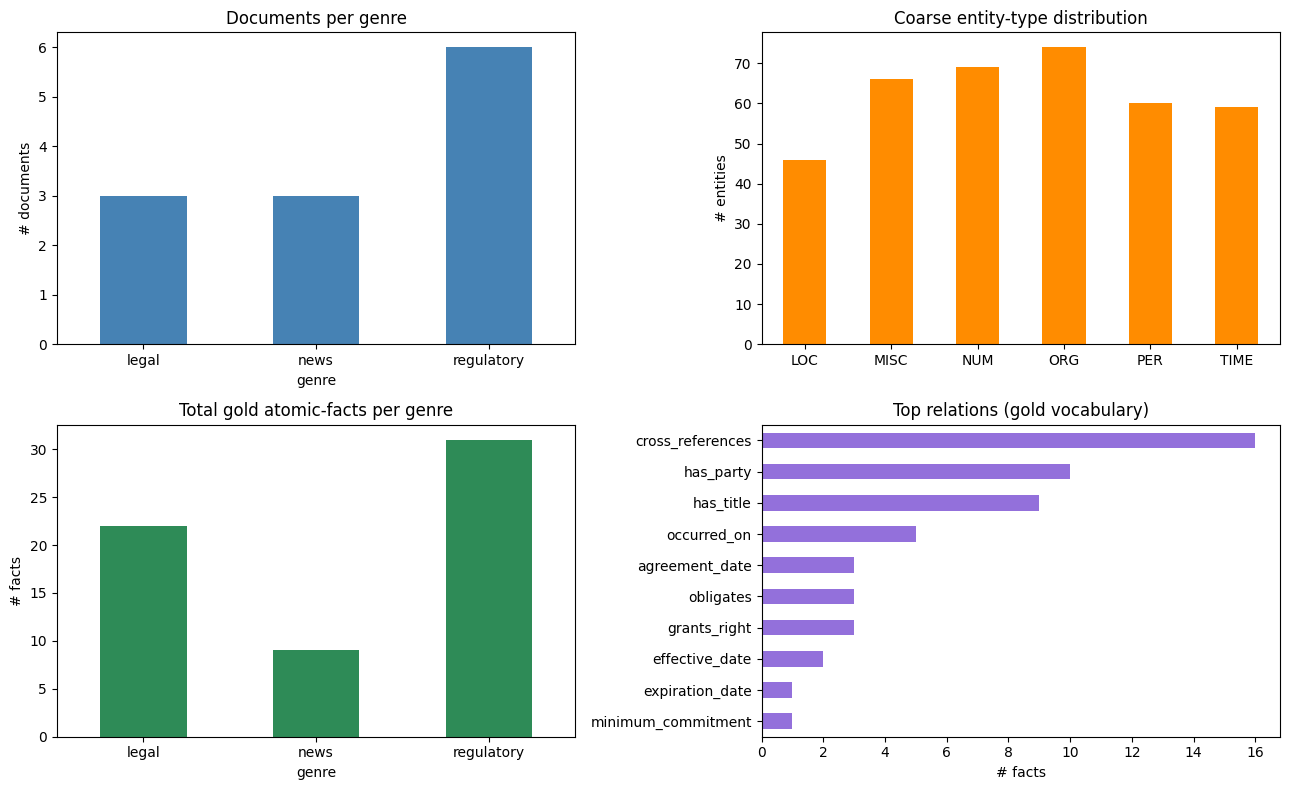


Saved figure -> demo_summary.png


In [10]:
# per-document summary table
recs = []
for ex in rows:
    inp = json.loads(ex["input"]); out = json.loads(ex["output"])
    recs.append({
        "doc_id": inp["doc_id"], "corpus": corpus_of(ex["metadata_source"]),
        "genre": inp["genre"], "quality": ex["metadata_gold_quality"],
        "char_length": inp["char_length"],
        "n_entities": len(inp["entities"]), "n_facts": len(out["gold_atomic_facts"]),
    })
df = pd.DataFrame(recs)
print("Per-document summary:")
print(df.to_string(index=False))

# four composition charts
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

df["genre"].value_counts().reindex(["legal", "news", "regulatory"]).plot(
    kind="bar", ax=ax[0, 0], color="steelblue", rot=0)
ax[0, 0].set_title("Documents per genre"); ax[0, 0].set_ylabel("# documents")

pd.Series(dict(type_counts)).reindex(sorted(COARSE)).fillna(0).plot(
    kind="bar", ax=ax[0, 1], color="darkorange", rot=0)
ax[0, 1].set_title("Coarse entity-type distribution"); ax[0, 1].set_ylabel("# entities")

df.groupby("genre")["n_facts"].sum().reindex(["legal", "news", "regulatory"]).plot(
    kind="bar", ax=ax[1, 0], color="seagreen", rot=0)
ax[1, 0].set_title("Total gold atomic-facts per genre"); ax[1, 0].set_ylabel("# facts")

top_rel = pd.Series(dict(rels.most_common(10)))[::-1]
top_rel.plot(kind="barh", ax=ax[1, 1], color="mediumpurple")
ax[1, 1].set_title("Top relations (gold vocabulary)"); ax[1, 1].set_xlabel("# facts")

plt.tight_layout()
plt.savefig("demo_summary.png", dpi=90, bbox_inches="tight")
plt.show()
print("\nSaved figure -> demo_summary.png")


## Summary

The demo loaded a 12-document, all-genre subset of the **Application Anchor** dataset and ran the
artifact's own tooling on it:

* **Verification** independently confirmed every entity char-span (`document_text[s:e] == name`),
  every fact provenance span, coarse-type validity, and head/tail entity-linking coverage — with
  **zero errors**, reproducing the dataset's headline guarantee.
* **`build_meta`** recomputed the composition: balanced genres, crisp (legal) vs silver
  (news/regulatory) gold, per-genre relation vocabularies, and char-length / facts-per-doc stats.

To scale up, raise `N_PER_GROUP` in the Config cell (3 = all of the demo file). The full dataset
(`full_data_out.json`, 24 docs, 8 per genre, 140 gold facts) is regenerated deterministically and
byte-identically from a cached raw snapshot via `python data.py` — **no network and no LLM** in
gold construction, which is what keeps the downstream hallucination-control experiment
non-circular.
